# Bengali Corpus: Zipf's Law, Heaps' Law & Cost Analysis

This notebook is a complete notebook conversion of the original `analysis.py` script.

It preserves **all original analysis sections, calculations, plots, thresholds, printed outputs, and cost assumptions**, while partitioning the workflow into executable notebook cells.

### Original workflow
1. Dependency setup
2. Bengali text-column detection
3. Bengali text cleaning
4. Tokenization
5. Zipf theoretical distribution
6. Zipf plot
7. Heaps' Law plot
8. CSV loading and validation
9. Zipf regression and KS test
10. Heaps' Law artifact investigation
11. Infrastructure & investment cost estimation


## 1. Imports and Dependency Checks

In [8]:
import sys
import os
import subprocess

try:
    import regex
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "regex"])
    import regex

try:
    import numpy as np
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy"])
    import numpy as np

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

try:
    from scipy import stats
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    from scipy import stats

try:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

from collections import Counter

## 2. Bengali Text Detection

In [2]:
BENGALI_BLOCK = r"[\u0980-\u09FF]"


def detect_bengali_text_column(df):
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    if not object_cols:
        raise ValueError("No object-typed columns found in the CSV.")

    best_col = None
    best_score = -1.0

    for col in object_cols:
        texts = df[col].dropna().astype(str).tolist()
        if not texts:
            continue
        bengali_texts = [str(t) for t in texts if regex.search(BENGALI_BLOCK, str(t))]
        if not bengali_texts:
            continue
        avg_len = float(np.mean([len(t) for t in bengali_texts]))
        if avg_len > best_score:
            best_score = avg_len
            best_col = col

    if best_col is None:
        raise ValueError("No Bengali text column could be detected.")

    return best_col

## 3. Bengali Text Cleaning and Tokenization

In [3]:
def clean_bengali_text(text):
    if text is None:
        return ""
    text = str(text)
    text = regex.sub(r"[^\u0980-\u09FF\s]+", " ", text)
    text = regex.sub(r"\s+", " ", text)
    return text.strip()


def safe_word_list_from_series(series):
    words = []
    for item in series:
        cleaned = clean_bengali_text(item)
        if not cleaned:
            continue
        tokens = regex.split(r"\s+", cleaned)
        words.extend([token for token in tokens if token])
    return words

## 4. Zipf's Law Helper Functions

In [4]:
def build_zipf_theoretical(rank_array, total_count):
    rank_array = np.asarray(rank_array, dtype=float)
    zipf_weights = 1.0 / rank_array
    zipf_weights = zipf_weights / zipf_weights.sum()
    return total_count * zipf_weights


def plot_zipf_analysis(ranks, frequencies, fitted_slope, intercept, total_count):
    sample_size = min(len(ranks), 5000)
    sample_idx = np.linspace(0, len(ranks) - 1, sample_size, dtype=int)
    x_plot = ranks[sample_idx]
    y_plot = frequencies[sample_idx]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.loglog(x_plot, y_plot, 'o', markersize=3, alpha=0.7, label='Observed corpus')

    x_theory = np.geomspace(1, max(ranks), 200)
    zipf_weights = 1.0 / np.arange(1, max(ranks) + 1, dtype=float)
    zipf_weights = zipf_weights / zipf_weights.sum()
    y_theory = total_count * zipf_weights[:len(x_theory)] if len(x_theory) <= len(zipf_weights) else total_count * zipf_weights
    if len(y_theory) < len(x_theory):
        y_theory = np.pad(y_theory, (0, len(x_theory) - len(y_theory)), mode='edge')
    ax.loglog(x_theory, y_theory, color='red', linewidth=2, label='Theoretical Zipf (alpha=1)')

    fit_line = np.exp(intercept + fitted_slope * np.log(x_theory))
    ax.loglog(x_theory, fit_line, color='green', linestyle='--', linewidth=2, label=f'Actual regression slope ({fitted_slope:.3f})')

    ax.set_title('Zipf Law Analysis')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('zipf_analysis.png', dpi=150)

## 5. Heaps' Law Plotting Function

In [5]:
def plot_heaps_analysis(N_values, V_values):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(N_values, V_values, marker='o', linewidth=2, color='blue')
    ax.set_title("Heaps' Law Artifact Investigation")
    ax.set_xlabel('Cumulative word count N')
    ax.set_ylabel('Cumulative unique words V')
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('heaps_analysis.png', dpi=150)
    plt.close(fig)

## 6. Input CSV

In the original script, the CSV was supplied through `sys.argv`.

For the notebook version, set the path below and run the cell.


In [6]:
# Set this to your input Bengali corpus CSV.
csv_path = "wiki.csv"

print(f"Input CSV: {csv_path}")


Input CSV: wiki.csv


## 7. Load and Validate the Corpus

In [9]:
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"ERROR: File not found: {csv_path}")

try:
    df = pd.read_csv(csv_path, low_memory=False)
except Exception as exc:
    raise RuntimeError(f"ERROR: Could not read CSV: {exc}") from exc

if df.empty:
    raise ValueError("ERROR: CSV file is empty.")

print(f"Loaded CSV successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
display(df.head())


Loaded CSV successfully.
Rows: 70,377
Columns: 4


,id,text,title,url
0,2341,বংশী বাংলাদেশের একটি ক্ষুদ্রতম উপজাতি। এরা টাঙ...,বংশী,https://bn.wikipedia.org/wiki?curid=2341
1,107282,আবহাওয়াবিদ্যা (বা আবহবিদ্যা) মানে এককথায় আবহ...,আবহাওয়াবিদ্যা,https://bn.wikipedia.org/wiki?curid=107282
2,107838,কোরিয়ার ওয়ার্কার্স পার্টি হল গণতান্ত্রিক গণপ...,কোরিয়ার ওয়ার্কার্স পার্টি,https://bn.wikipedia.org/wiki?curid=107838
3,4542,মোহাম্মদ মোস্তফা কামাল (১৬ ডিসেম্বর ১৯৪৭ - এপ্...,মোস্তফা কামাল (বীরশ্রেষ্ঠ),https://bn.wikipedia.org/wiki?curid=4542
4,4626,মণিপুরী সংস্কৃতির উজ্জ্বলতম দিক হলো মণিপুরী নৃ...,মণিপুরী (নৃত্য),https://bn.wikipedia.org/wiki?curid=4626


## 8. Detect Bengali Column and Build the Word Corpus

In [10]:
try:
    text_col = detect_bengali_text_column(df)
except ValueError as exc:
    raise ValueError(f"ERROR: {exc}") from exc

clean_series = df[text_col].dropna().astype(str)
all_words = safe_word_list_from_series(clean_series)

if not all_words:
    raise ValueError("ERROR: No Bengali words were found after cleaning.")

total_words = len(all_words)
unique_words = len(set(all_words))

print(f"Detected Bengali text column: {text_col}")
print(f"Total word count (N): {total_words}")
print(f"Unique word count (V): {unique_words}")


Detected Bengali text column: text
Total word count (N): 17586583
Unique word count (V): 607534


## 9. Zipf's Law Analysis

In [12]:
    freq_counter = Counter(all_words)
    ranked_counts = sorted(freq_counter.values(), reverse=True)
    ranks = np.arange(1, len(ranked_counts) + 1, dtype=float)
    frequencies = np.asarray(ranked_counts, dtype=float)

    valid = frequencies > 0
    if np.sum(valid) < 2:
        print("ERROR: Not enough unique word frequencies to compute Zipf analysis.", file=sys.stderr)
        sys.exit(1)

    log_ranks = np.log(ranks[valid])
    log_freqs = np.log(frequencies[valid])
    slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
    alpha = -slope

    theoretical_counts = build_zipf_theoretical(ranks, total_words)
    ks_stat, ks_p_value = stats.ks_2samp(frequencies, theoretical_counts)

    print(f"Alpha value: {alpha:.6f}")
    print(f"KS p-value: {ks_p_value:.6e}")
    if ks_p_value < 0.05 or abs(alpha - 1.0) > 0.1:
        print("ZIPF'S LAW DISPROVED")

    plot_zipf_analysis(ranks, frequencies, slope, intercept, total_words)

Alpha value: 1.278747
KS p-value: 0.000000e+00
ZIPF'S LAW DISPROVED


### Zipf Plot

The original script saves the generated figure as `zipf_analysis.png`.

The function above is unchanged, so running the Zipf analysis cell creates that same plot file.


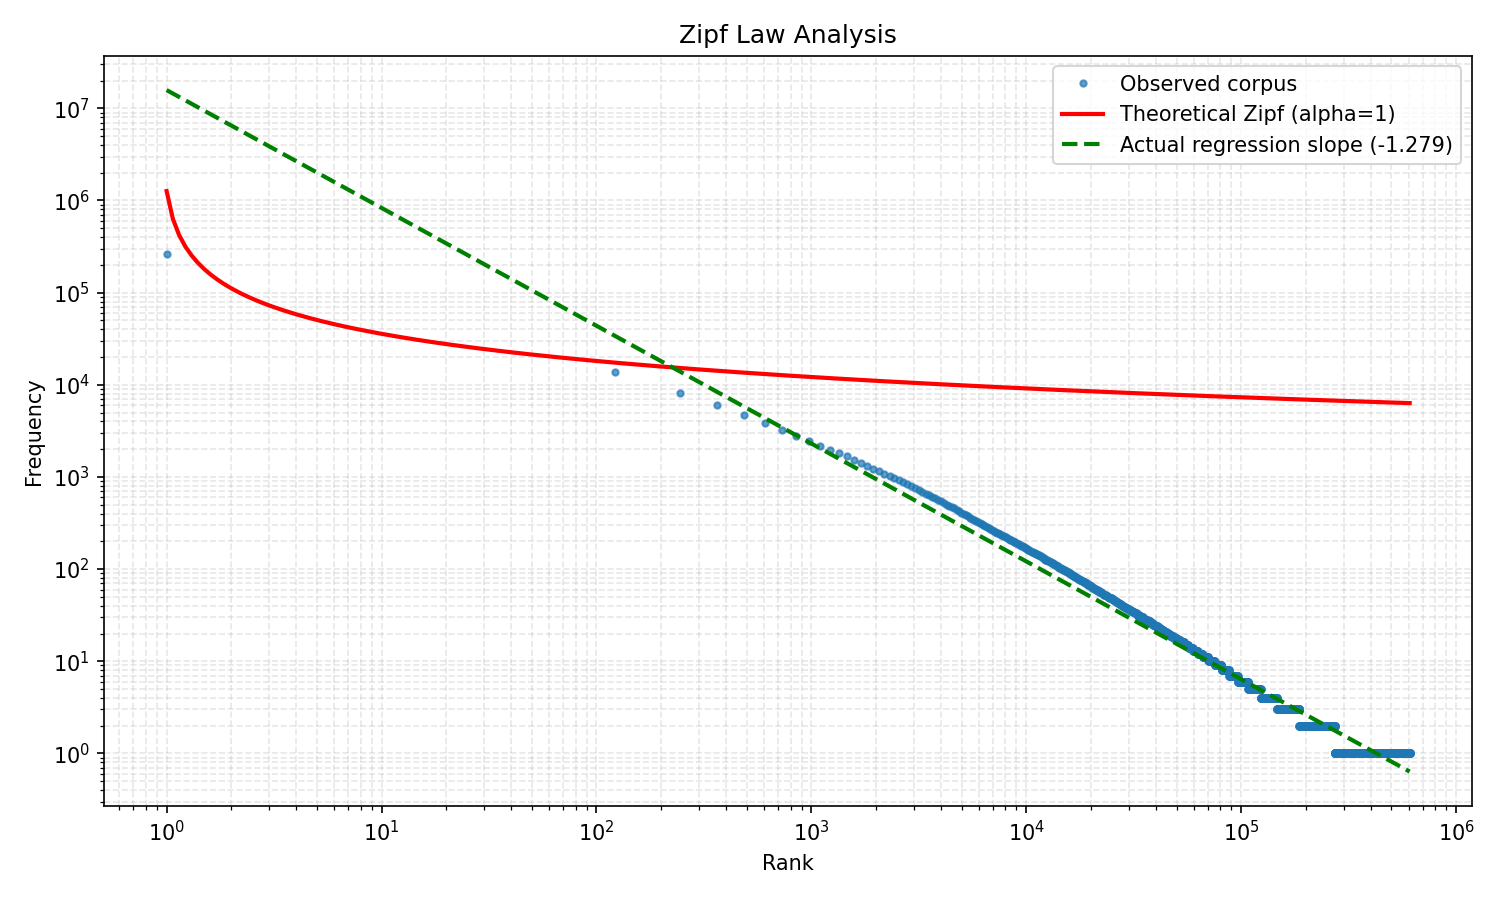

In [13]:
# Display the generated Zipf plot inside the notebook.
from IPython.display import Image, display

if os.path.exists("zipf_analysis.png"):
    display(Image(filename="zipf_analysis.png"))
else:
    print("Run the Zipf's Law Analysis cell first.")


## 10. Heaps' Law Artifact Investigation

In [14]:
    seen_words = set()
    artifact_n_values = []
    artifact_samples = []
    N_values = []
    V_values = []

    for start_idx in range(0, len(all_words), 10000):
        chunk = all_words[start_idx:start_idx + 10000]
        chunk_new_words = []
        for word in chunk:
            if word not in seen_words:
                seen_words.add(word)
                chunk_new_words.append(word)

        cumulative_n = min(start_idx + len(chunk), len(all_words))
        cumulative_v = len(seen_words)
        N_values.append(cumulative_n)
        V_values.append(cumulative_v)

        if len(chunk_new_words) > 0.35 * len(chunk):
            artifact_n_values.append(cumulative_n)
            artifact_samples.append(chunk_new_words[:15])
            print(f"Artifact at cumulative N = {cumulative_n}: new unique words = {len(chunk_new_words)}; chunk size = {len(chunk)}")
            print("Sample of 15 new words:", ", ".join(chunk_new_words[:15]))

    plot_heaps_analysis(N_values, V_values)

Artifact at cumulative N = 10000: new unique words = 3974; chunk size = 10000
Sample of 15 new words: বংশী, বাংলাদেশের, একটি, ক্ষুদ্রতম, উপজাতি, এরা, টাঙ্গাইল, জেলার, মহানান্দপুর, এবং, দন্দোনিয়া, নামে, পাশাপাশি, দুইটি, গ্রামের


In [17]:
# Fit Heaps' Law: V = kN^beta
log_N = np.log(N_values)
log_V = np.log(V_values)
beta, log_k = np.polyfit(log_N, log_V, 1)
k = np.exp(log_k)

print(f"Heaps' Law parameters: k = {k:.6f}, beta = {beta:.6f}")

Heaps' Law parameters: k = 10.992789, beta = 0.653417


### Heaps Plot

The original script saves the generated figure as `heaps_analysis.png`.

The plotting function and its original artifact threshold are preserved.


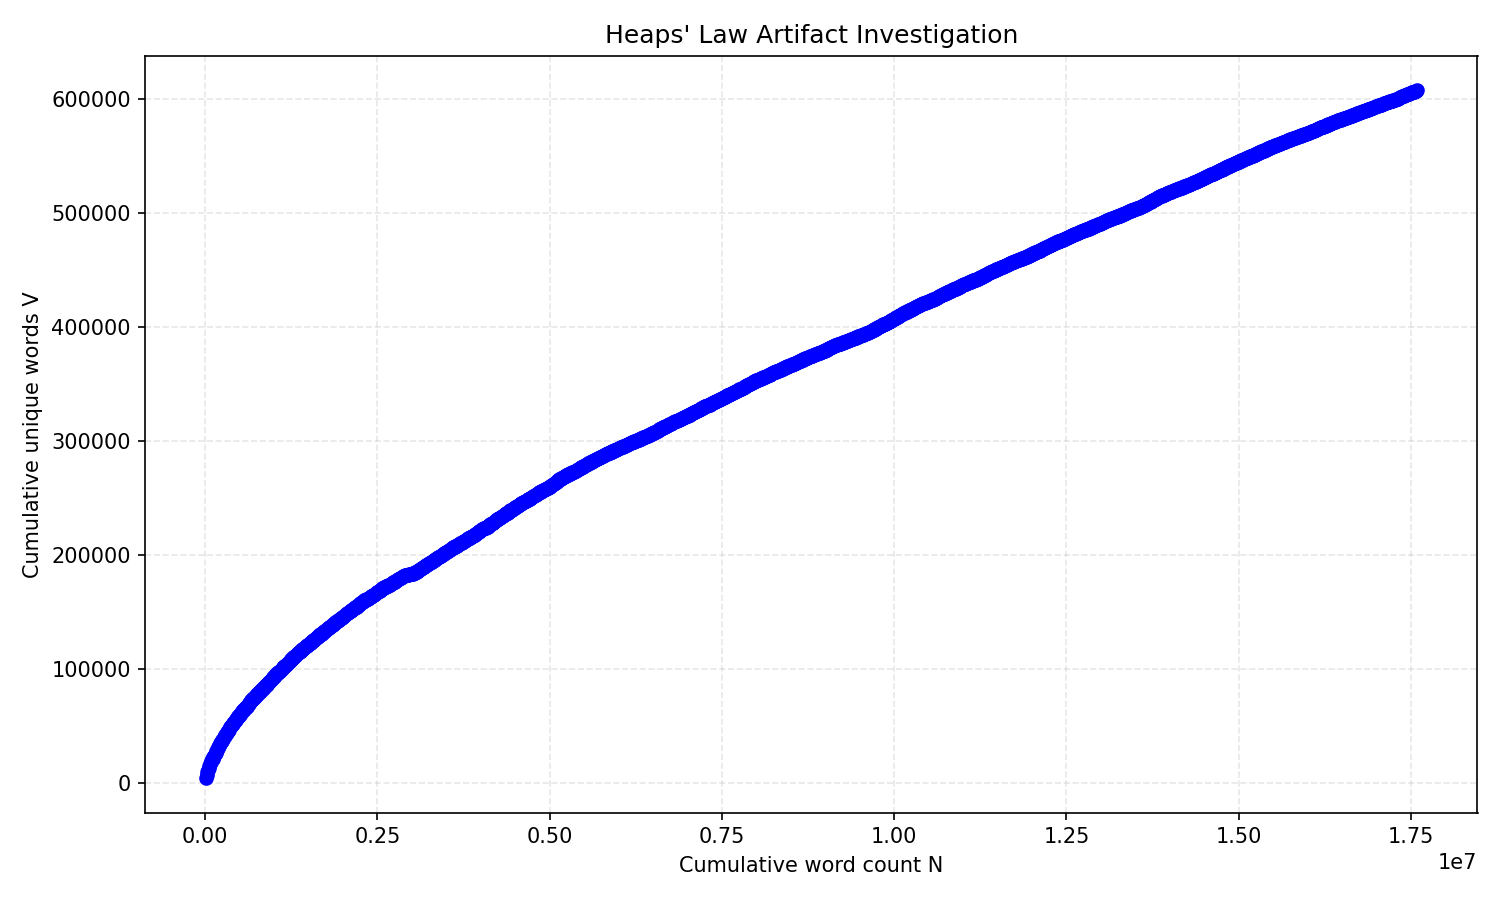

In [15]:
# Display the generated Heaps plot inside the notebook.
if os.path.exists("heaps_analysis.png"):
    display(Image(filename="heaps_analysis.png"))
else:
    print("Run the Heaps' Law Artifact Investigation cell first.")


## 11. Infrastructure & Investment Cost Estimation

In [16]:
    processing_cost = (total_words / 100000.0) * 1000.0
    sarvam_data_cost = (4_000_000_000.0 / 100000.0) * 1000.0
    sarvam_total = sarvam_data_cost + 150000.0 + 144000.0 + 300000.0
    google_data_cost = (200_000_000.0 / 100000.0) * 1000.0
    google_total = google_data_cost + 3000000.0 + 15000000.0

    print("\nINFRASTRUCTURE & INVESTMENT COST ESTIMATION")
    print(f"{'Scenario':<36} {'Estimated cost (USD)':>22}")
    print("-" * 60)
    print(f"{'Current CSV file processing':<36} ${processing_cost:>18,.2f}")
    print(f"{'Sarvam AI (Generative LLM)':<36} ${sarvam_total:>18,.2f}")
    print(f"{'Google Search (Retrieval)':<36} ${google_total:>18,.2f}")


INFRASTRUCTURE & INVESTMENT COST ESTIMATION
Scenario                               Estimated cost (USD)
------------------------------------------------------------
Current CSV file processing          $        175,865.83
Sarvam AI (Generative LLM)           $     40,594,000.00
Google Search (Retrieval)            $     20,000,000.00


## 12. Generated Outputs

Running the notebook produces the same two plot files as the original script:

- `zipf_analysis.png`
- `heaps_analysis.png`

The notebook also retains the original printed numerical results, including:

- Bengali text column
- Total word count
- Unique word count
- Zipf exponent (`alpha`)
- KS p-value
- Zipf's Law decision
- Heaps' Law artifact locations and samples
- Current CSV processing cost
- Sarvam AI estimated cost
- Google Search estimated cost
